## **Prediction of the Probability of default**

In [1]:
# import the python libraries 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# import the 
df = pd.read_csv("bank.csv")
df.head()

,loan_applicant_id,age,education,years_with_current_employer,years_at_current_address,household_income,debt_to_income_ratio,credit_card_debt,other_debt,y
0,191,44,university.degree,10,20,192,12.116645,14.377313,8.886645,1
1,34318,34,high.school,3,18,57,14.264229,5.137880,2.992730,0
2,14932,45,university.degree,14,24,212,7.285681,10.460306,4.985339,0
3,2776,33,illiterate,12,5,418,11.386272,3.040189,44.554429,1
4,11915,20,basic,4,19,122,28.418494,14.560450,20.110112,0


In [3]:
# create dummy variables from the education column 
# the dummy variables will be in columns with education attacheed to the column names

cat_vars = ["education"]
for var in cat_vars:
    cat_list = "var" + "_" + var
    cat_list = pd.get_dummies(df[var], prefix=var)
    data1 = df.join(cat_list)
    df = data1
cat_vars = ["education"]
data_vars = df.columns.values.tolist()
to_keep = [i for i in data_vars if i not in cat_vars]

In [4]:
# drop the id of the loan application in the data
# view the data

df_final = df[to_keep]
df_final.drop(["loan_applicant_id"], axis=1, inplace=True)
df_final.tail()

C:\Users\user\AppData\Local\Temp\ipykernel_10164\1586690431.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.drop(["loan_applicant_id"], axis=1, inplace=True)


,age,years_with_current_employer,years_at_current_address,household_income,debt_to_income_ratio,credit_card_debt,other_debt,y,education_basic,education_high.school,education_illiterate,education_professional.course,education_university.degree
41183,49,4,4,114,12.296137,4.868954,9.148643,0,False,True,False,False,False
41184,52,13,16,178,21.421341,23.210634,14.919353,0,False,False,False,True,False
41185,42,18,15,264,9.821804,12.290464,13.639099,1,False,False,False,False,True
41186,21,12,24,56,23.998647,8.108453,5.330789,0,False,False,False,False,True
41187,56,25,1,240,28.722250,35.620750,33.312650,0,False,True,False,False,False


In [5]:
# verify the information on the dataset
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   years_with_current_employer    41188 non-null  int64  
 2   years_at_current_address       41188 non-null  int64  
 3   household_income               41188 non-null  int64  
 4   debt_to_income_ratio           41188 non-null  float64
 5   credit_card_debt               41188 non-null  float64
 6   other_debt                     41188 non-null  float64
 7   y                              41188 non-null  int64  
 8   education_basic                41188 non-null  bool   
 9   education_high.school          41188 non-null  bool   
 10  education_illiterate           41188 non-null  bool   
 11  education_professional.course  41188 non-null  bool   
 12  education_university.degree    41188 non-null 

In [6]:
# researching for missing values
df_final.isnull().sum()

age                              0
years_with_current_employer      0
years_at_current_address         0
household_income                 0
debt_to_income_ratio             0
credit_card_debt                 0
other_debt                       0
y                                0
education_basic                  0
education_high.school            0
education_illiterate             0
education_professional.course    0
education_university.degree      0
dtype: int64

In [7]:
df_final.describe()

,age,years_with_current_employer,years_at_current_address,household_income,debt_to_income_ratio,credit_card_debt,other_debt,y
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,38.007842,13.549869,15.385331,139.707366,16.224054,9.577260,13.758168,0.112654
std,10.623627,8.145105,9.184471,81.688037,9.191426,12.408628,14.596510,0.316173
min,20.000000,0.000000,0.000000,14.000000,0.400386,0.005668,0.021759,0.000000
25%,29.000000,6.000000,7.000000,74.000000,8.452497,1.853292,3.783906,0.000000
50%,38.000000,14.000000,15.000000,134.000000,16.105334,5.311447,9.153871,0.000000
75%,47.000000,21.000000,23.000000,196.000000,23.730786,12.636789,18.906855,0.000000
max,56.000000,29.000000,31.000000,446.000000,41.293984,149.015859,159.198221,1.000000


In [8]:
# Give the Y column a new name Target for clarity purposes
df1 = df_final.rename(columns={'y': 'Target'})

In [9]:
df1.head()

,age,years_with_current_employer,years_at_current_address,household_income,debt_to_income_ratio,credit_card_debt,other_debt,Target,education_basic,education_high.school,education_illiterate,education_professional.course,education_university.degree
0,44,10,20,192,12.116645,14.377313,8.886645,1,False,False,False,False,True
1,34,3,18,57,14.264229,5.137880,2.992730,0,False,True,False,False,False
2,45,14,24,212,7.285681,10.460306,4.985339,0,False,False,False,False,True
3,33,12,5,418,11.386272,3.040189,44.554429,1,False,False,True,False,False
4,20,4,19,122,28.418494,14.560450,20.110112,0,True,False,False,False,False


In [10]:
# check the distribution of defaul and non-default borrowers
df1["Target"].value_counts()

Target
0    36548
1     4640
Name: count, dtype: int64

### **This data is highly imbalanced or unbalanced, 88.7% to 11.3%** 

#### **1--> Default**  

#### **0--> Non-default**

In [11]:
# separate the data for analysis and print their shapes
Def = df1[df1.Target == 1]
Non_def = df1[df1.Target == 0]

print(Def.shape)
print(Non_def.shape)

(4640, 13)
(36548, 13)


#### We will undertake **undersampling process** as this will give a uniform distribution for default and non-default  

#### RandomForestClassifier is not rubost to imbalance data but **SVM, KNN, & LogisticRegression models** are sensitive to imbalance data 

#### Number of default--> 4640

In [12]:
# randomly select 4640 samples from the Non_default to balance the distribution
Non_def_balance = Non_def.sample(n=4640, random_state=9)
Non_def_balance.head()

print(Non_def_balance.shape)
print(Def.shape)

(4640, 13)
(4640, 13)


In [13]:
# concate or join the two data frames to form a single balanced data frame of equal distribution
df1_balanced = pd.concat([Non_def_balance, Def], axis = 0)
df1_balanced.tail()

# print the shapes to verify they added up correctly
print(df1_balanced.columns)
print(df1_balanced.shape)

df1_balanced.tail(3)

Index(['age', 'years_with_current_employer', 'years_at_current_address',
       'household_income', 'debt_to_income_ratio', 'credit_card_debt',
       'other_debt', 'Target', 'education_basic', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree'],
      dtype='object')
(9280, 13)


,age,years_with_current_employer,years_at_current_address,household_income,debt_to_income_ratio,credit_card_debt,other_debt,Target,education_basic,education_high.school,education_illiterate,education_professional.course,education_university.degree
41177,40,10,8,321,18.152318,35.778749,22.490192,1,True,False,False,False,False
41181,53,7,19,260,19.476219,6.707010,43.931160,1,True,False,False,False,False
41185,42,18,15,264,9.821804,12.290464,13.639099,1,False,False,False,False,True


#### **importing libraries for the various modeling methods**

In [14]:
import warnings

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV



warnings.filterwarnings("ignore")

In [15]:
# create the y variable and X varibles
y = df1_balanced.loc[:, df1_balanced.columns == "Target"]
X = df1_balanced.loc[:, df1_balanced.columns != "Target"]
print(y.shape)
print(X.shape)

(9280, 1)
(9280, 12)


In [16]:
# splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_test.shape)

(7424, 12)
(1856, 1)


In [17]:
# standardize the X datasets to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Hyperparameter tunning** to find the best hyperparameters for the model using **GridSearchCV**

In [18]:
# defining the range of the hyperparameters
param_grid = {
    "n_estimators": [10, 20, 50, 100],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 4, 8]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=8), param_grid, refit=True, verbose=3, cv=3
)

# fitting the model for grid search
grid.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV 1/3] END max_depth=2, min_samples_split=2, n_estimators=10;, score=0.804 total time=   0.0s
[CV 2/3] END max_depth=2, min_samples_split=2, n_estimators=10;, score=0.773 total time=   0.0s
[CV 3/3] END max_depth=2, min_samples_split=2, n_estimators=10;, score=0.788 total time=   0.0s
[CV 1/3] END max_depth=2, min_samples_split=2, n_estimators=20;, score=0.809 total time=   0.0s
[CV 2/3] END max_depth=2, min_samples_split=2, n_estimators=20;, score=0.802 total time=   0.0s
[CV 3/3] END max_depth=2, min_samples_split=2, n_estimators=20;, score=0.802 total time=   0.0s
[CV 1/3] END max_depth=2, min_samples_split=2, n_estimators=50;, score=0.811 total time=   0.2s
[CV 2/3] END max_depth=2, min_samples_split=2, n_estimators=50;, score=0.802 total time=   0.2s
[CV 3/3] END max_depth=2, min_samples_split=2, n_estimators=50;, score=0.802 total time=   0.2s
[CV 1/3] END max_depth=2, min_samples_split=2, n_estimators=100;, score=0.

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=8),
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_split': [2, 4, 8],
                         'n_estimators': [10, 20, 50, 100]},
             verbose=3)

In [19]:
# prin best parameter after tunning
print(grid.best_params_)

# print best estimator
print(grid.best_estimator_)

{'max_depth': 5, 'min_samples_split': 8, 'n_estimators': 20}
RandomForestClassifier(max_depth=5, min_samples_split=8, n_estimators=20,
                       random_state=8)


In [20]:
# our model is the RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators = 20,
    max_depth = 5,
    min_samples_split = 8,
    random_state = 42           
)

In [21]:
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring="f1")
print("\nCross_validation F1 scores:", cv_scores)
print("Average F1_score", np.mean(cv_scores))


Cross_validation F1 scores: [0.79352227 0.78994323 0.7828201  0.78040816 0.78640777]
Average F1_score 0.7866203045212481


In [22]:
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=5, min_samples_split=8, n_estimators=20,
                       random_state=42)

In [23]:
print("\n Accuracy: %0.4f" % (rf_model.score(X_train, y_train)))
print("\n Accuracy: %0.4f" % (rf_model.score(X_test, y_test)))


 Accuracy: 0.5031

 Accuracy: 0.5156


In [24]:
y_pred = rf_model.predict(X_test_scaled)

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.99      0.84       914
           1       0.99      0.64      0.78       942

    accuracy                           0.81      1856
   macro avg       0.86      0.82      0.81      1856
weighted avg       0.86      0.81      0.81      1856



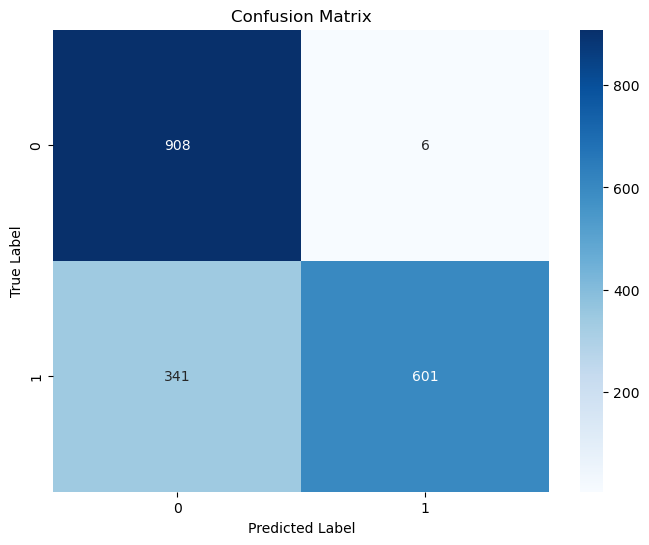

In [26]:
# confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [27]:
# the importants of features in determining the prediciions
importance = rf_model.feature_importances_
feature_imp = pd.DataFrame({
    "features": X.columns,
    "importance": importance
}).sort_values("importance", ascending = False)

In [28]:
feature_imp.head()

,features,importance
3,household_income,0.366103
4,debt_to_income_ratio,0.225169
5,credit_card_debt,0.187827
6,other_debt,0.117068
1,years_with_current_employer,0.051585


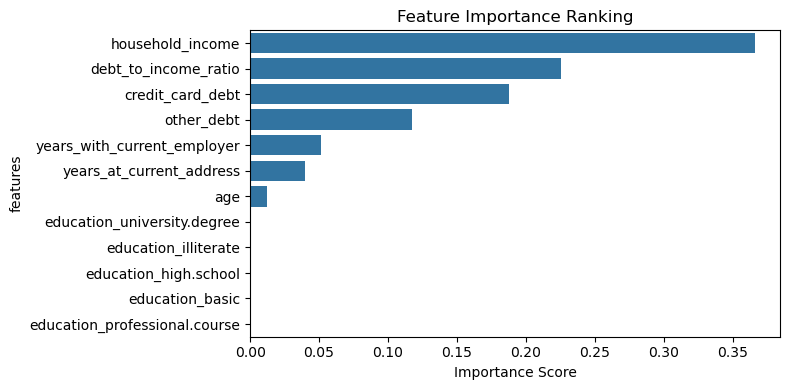

In [29]:
# graphical representation of the feature importance
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_imp, y="features", x="importance")
plt.title("Feature Importance Ranking")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [31]:
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

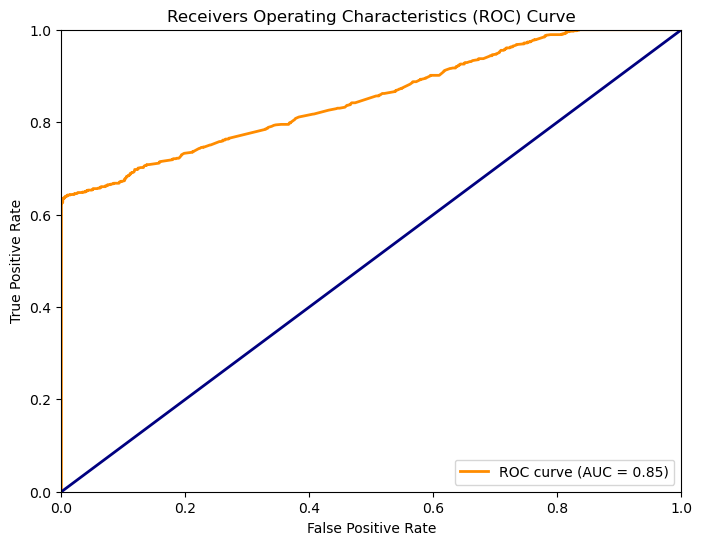

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="-")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receivers Operating Characteristics (ROC) Curve")
plt.legend(loc= "lower right")
plt.show()

## **Conclusion**  



Our model performed fairly well in predicting loan default and non-default. The most important factor that determines whether  
there will be a default is the household income, while the least is education according to the model. notebly, the train set has  
less accuracy than the test set, perhaps, due to hyperparameter selection, random seed and split quality, and data sampling and subset difficulty.